# Mood Regression Model (1–5 Scale)

This notebook:
- Loads GoEmotions dataset
- Maps emotions to a 1–5 mood scale
- Performs EDA
- Fine-tunes DistilBERT for regression
- Evaluates and saves the model


In [1]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate
import torch

In [3]:
dataset = load_dataset('go_emotions')
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [4]:
emotion_names = dataset['train'].features['labels'].feature.names

positive5 = ['joy','love','gratitude','admiration','excitement','optimism']
positive4 = ['approval','amusement','desire','caring','relief','pride']
neutral3  = ['neutral','curiosity','surprise']
negative2 = ['sadness','disappointment','embarrassment','nervousness']
negative1 = ['anger','fear','disgust','grief','remorse','annoyance']

mood_map = {}
for emo in positive5: mood_map[emo] = 5
for emo in positive4: mood_map[emo] = 4
for emo in neutral3:  mood_map[emo] = 3
for emo in negative2: mood_map[emo] = 2
for emo in negative1: mood_map[emo] = 1


In [5]:
def convert_to_mood(example):
    moods = []
    for label_id in example['labels']:
        emotion = emotion_names[label_id]
        if emotion in mood_map:
            moods.append(mood_map[emotion])
    example['mood'] = sum(moods)/len(moods) if moods else 3
    return example

dataset = dataset.map(convert_to_mood)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

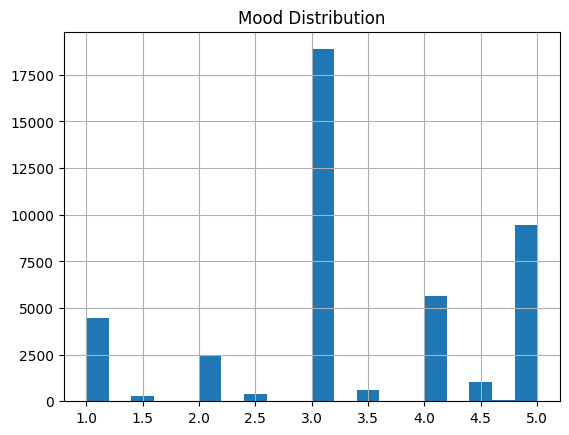

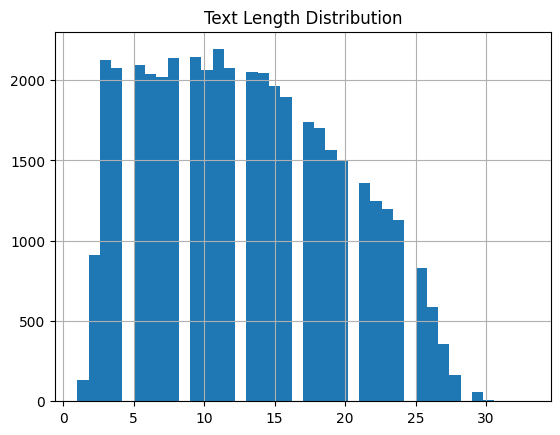

,mood,length
count,43410.000000,43410.000000
mean,3.334623,12.840175
std,1.201223,6.701597
min,1.000000,1.000000
25%,3.000000,7.000000
50%,3.000000,12.000000
75%,4.000000,18.000000
max,5.000000,33.000000


In [6]:
train_df = pd.DataFrame(dataset['train'])

train_df['mood'].hist(bins=20)
plt.title('Mood Distribution')
plt.show()

train_df['length'] = train_df['text'].apply(lambda x: len(x.split()))
train_df['length'].hist(bins=40)
plt.title('Text Length Distribution')
plt.show()

train_df[['mood','length']].describe()

In [7]:
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding=True)

dataset = dataset.map(tokenize, batched=True)

dataset = dataset.remove_columns(['text','labels','id'])
dataset = dataset.rename_column('mood','labels')
dataset.set_format('torch')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1
)
model.config.problem_type = 'regression'

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
mse_metric = evaluate.load('mse')

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.squeeze()
    mse = mse_metric.compute(predictions=predictions, references=labels)['mse']
    rmse = np.sqrt(mse)
    return {'mse': mse, 'rmse': rmse}

training_args = TrainingArguments(
    output_dir='./mood_model',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True
)
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,   # <-- important
)

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Mse,Rmse
1,0.579203,0.533991,0.533991,0.730747
2,0.442759,0.536558,0.536558,0.732501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5428, training_loss=0.5794166306317863, metrics={'train_runtime': 294.0755, 'train_samples_per_second': 295.23, 'train_steps_per_second': 18.458, 'total_flos': 3444232722472152.0, 'train_loss': 0.5794166306317863, 'epoch': 2.0})

In [10]:
results = trainer.evaluate()
results

{'eval_loss': 0.5339228510856628,
 'eval_mse': 0.5339228289664454,
 'eval_rmse': 0.730700231946347,
 'eval_runtime': 2.9583,
 'eval_samples_per_second': 1834.17,
 'eval_steps_per_second': 114.931,
 'epoch': 2.0}

In [12]:
def predict_mood(text):
    device = model.device  # gets whether model is on cpu or cuda

    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}  # move to same device

    with torch.no_grad():
        outputs = model(**inputs)

    return round(outputs.logits.squeeze().item(), 2)

print(predict_mood('I feel amazing and excited about life!'))
print(predict_mood('I feel exhausted and hopeless today.'))

4.98
2.21


In [13]:
trainer.save_model('mood_regression_model')
tokenizer.save_pretrained('mood_regression_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('mood_regression_model/tokenizer_config.json',
 'mood_regression_model/tokenizer.json')

In [14]:
from google.colab import files
!zip -r mood_model.zip mood_regression_model
files.download("mood_model.zip")

  adding: mood_regression_model/ (stored 0%)
  adding: mood_regression_model/tokenizer_config.json (deflated 42%)
  adding: mood_regression_model/tokenizer.json (deflated 71%)
  adding: mood_regression_model/model.safetensors (deflated 8%)
  adding: mood_regression_model/training_args.bin (deflated 53%)
  adding: mood_regression_model/config.json (deflated 49%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>